# Sprint 5: Simulación de Impacto Económico (ROI)

Traducimos las predicciones probabilísticas del modelo final Stacking Classifier en valor de negocio utilizando la matriz costo-beneficio del Sprint 1. Buscamos el umbral óptimo de decisión que maximiza el retorno financiero esperado en el conjunto de prueba.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from matplotlib.patches import Wedge, Circle
from matplotlib.lines import Line2D

In [57]:
# 1. Cargar datos y modelo
# =========================================================

DATA_PATH = Path("../data/interim/employee_performance_features.csv")
MODELS_DIR = Path("../models")

MODEL_CANDIDATES = [
    MODELS_DIR / "validated_final_model.pkl",
    MODELS_DIR / "final_model.pkl",
    MODELS_DIR / "tuned_knn_optuna.pkl",
    MODELS_DIR / "best_tuned_model.pkl"
]

MODEL_PATH = None

for path in MODEL_CANDIDATES:
    if path.exists():
        MODEL_PATH = path
        break

if MODEL_PATH is None:
    raise FileNotFoundError("No se encontró ningún modelo final disponible.")

df = pd.read_csv(DATA_PATH)

target = "attrition"

X = df.drop(columns=[target])
y = df[target]

if "employee_id" in X.columns:
    X = X.drop(columns=["employee_id"])

model = joblib.load(MODEL_PATH)

print("Modelo cargado:", MODEL_PATH)
print("Shape X:", X.shape)
print("Shape y:", y.shape)

print("\nDistribución target:")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

Modelo cargado: ..\models\validated_final_model.pkl
Shape X: (14000, 35)
Shape y: (14000,)

Distribución target:
attrition
0    11840
1     2160
Name: count, dtype: int64
attrition
0    0.846
1    0.154
Name: proportion, dtype: float64


In [58]:
# 2. Split consistente
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_test:", X_test.shape)

print("\nDistribución test:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True).round(3))

X_test: (2800, 35)

Distribución test:
attrition
0    2368
1     432
Name: count, dtype: int64
attrition
0    0.846
1    0.154
Name: proportion, dtype: float64


In [59]:
# 3. Probabilidades del modelo
# =========================================================

if not hasattr(model, "predict_proba"):
    raise AttributeError("El modelo cargado no tiene predict_proba().")

y_proba = model.predict_proba(X_test)[:, 1]

auc_roc = roc_auc_score(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)
base_rate = y_test.mean()

print("AUC-ROC:", round(auc_roc, 4))
print("Average Precision:", round(avg_precision, 4))
print("Tasa base attrition:", round(base_rate, 4))

AUC-ROC: 0.4975
Average Precision: 0.1529
Tasa base attrition: 0.1543


In [109]:
# 4. Matriz costo-beneficio
# =========================================================

benefit_tp = 300
cost_fp = -20
cost_fn = -100
benefit_tn = 50

cost_matrix = pd.DataFrame([
    {
        "caso": "TP",
        "significado": "Empleado con attrition correctamente detectado",
        "valor_unitario": benefit_tp
    },
    {
        "caso": "FP",
        "significado": "Empleado intervenido innecesariamente",
        "valor_unitario": cost_fp
    },
    {
        "caso": "FN",
        "significado": "Empleado con attrition no detectado",
        "valor_unitario": cost_fn
    },
    {
        "caso": "TN",
        "significado": "Empleado sin attrition correctamente no intervenido",
        "valor_unitario": benefit_tn
    }
])

display(cost_matrix)

,caso,significado,valor_unitario
0,TP,Empleado con attrition correctamente detectado,300
1,FP,Empleado intervenido innecesariamente,-20
2,FN,Empleado con attrition no detectado,-100
3,TN,Empleado sin attrition correctamente no interv...,50


In [110]:
# 5. Funciones de evaluación económica
# =========================================================

def calcular_valor(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    valor_total = (
        tp * benefit_tp +
        fp * cost_fp +
        fn * cost_fn +
        tn * benefit_tn
    )

    return {
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "empleados_intervenidos": int(y_pred.sum()),
        "pct_intervenido": y_pred.mean(),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "valor_total": valor_total,
        "valor_promedio_por_empleado": valor_total / len(y_true)
    }


def evaluar_umbral(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)

    resultado = calcular_valor(y_true, y_pred)
    resultado["threshold"] = threshold

    return resultado

In [111]:
# 6. Evaluación con threshold 0.5
# =========================================================

resultado_05 = evaluar_umbral(
    y_test,
    y_proba,
    threshold=0.5
)

df_resultado_05 = pd.DataFrame([resultado_05])

display(df_resultado_05)

y_pred_05 = (y_proba >= 0.5).astype(int)

print(classification_report(
    y_test,
    y_pred_05,
    zero_division=0
))

,tn,fp,fn,tp,empleados_intervenidos,pct_intervenido,accuracy,precision,recall,f1,valor_total,valor_promedio_por_empleado,threshold
0,545,1823,98,334,2157,0.770357,0.313929,0.154845,0.773148,0.258015,81190,28.996429,0.5


              precision    recall  f1-score   support

           0       0.85      0.23      0.36      2368
           1       0.15      0.77      0.26       432

    accuracy                           0.31      2800
   macro avg       0.50      0.50      0.31      2800
weighted avg       0.74      0.31      0.35      2800



In [112]:
# 7. Búsqueda de threshold sin restricción operativa
# =========================================================

thresholds = np.arange(0.01, 0.99, 0.01)

threshold_results = []

for t in thresholds:
    threshold_results.append(
        evaluar_umbral(y_test, y_proba, t)
    )

df_thresholds = pd.DataFrame(threshold_results)

df_thresholds = df_thresholds[
    [
        "threshold",
        "tn", "fp", "fn", "tp",
        "empleados_intervenidos",
        "pct_intervenido",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "valor_total",
        "valor_promedio_por_empleado"
    ]
]

display(
    df_thresholds.sort_values("valor_total", ascending=False).head(10)
)

,threshold,tn,fp,fn,tp,empleados_intervenidos,pct_intervenido,accuracy,precision,recall,f1,valor_total,valor_promedio_por_empleado
43,0.44,397,1971,63,369,2340,0.835714,0.273571,0.157692,0.854167,0.266234,84830,30.296429
47,0.48,519,1849,86,346,2195,0.783929,0.308929,0.157631,0.800926,0.263418,84170,30.060714
44,0.45,413,1955,69,363,2318,0.827857,0.277143,0.156601,0.840278,0.264000,83550,29.839286
45,0.46,419,1949,71,361,2310,0.825000,0.278571,0.156277,0.835648,0.263311,83170,29.703571
46,0.47,450,1918,77,355,2273,0.811786,0.287500,0.156181,0.821759,0.262477,82940,29.621429
19,0.20,30,2338,5,427,2765,0.987500,0.163214,0.154430,0.988426,0.267125,82340,29.407143
1,0.02,1,2367,0,432,2799,0.999643,0.154643,0.154341,1.000000,0.267409,82310,29.396429
2,0.03,1,2367,0,432,2799,0.999643,0.154643,0.154341,1.000000,0.267409,82310,29.396429
0,0.01,1,2367,0,432,2799,0.999643,0.154643,0.154341,1.000000,0.267409,82310,29.396429
20,0.21,34,2334,6,426,2760,0.985714,0.164286,0.154348,0.986111,0.266917,82220,29.364286


In [113]:
best_unrestricted = df_thresholds.loc[
    df_thresholds["valor_total"].idxmax()
]

print("Threshold óptimo sin restricción:", round(best_unrestricted["threshold"], 2))
print("Valor sin restricción:", round(best_unrestricted["valor_total"], 2))
print("% intervenido:", round(best_unrestricted["pct_intervenido"] * 100, 2), "%")

Threshold óptimo sin restricción: 0.44
Valor sin restricción: 84830.0
% intervenido: 83.57 %


Threshold óptimo con restricción operativa

In [114]:


MAX_INTERVENTION_RATE = 0.30

df_thresholds_restricted = df_thresholds[
    df_thresholds["pct_intervenido"] <= MAX_INTERVENTION_RATE
].copy()

if df_thresholds_restricted.empty:
    raise ValueError("No hay thresholds que cumplan la restricción operativa.")

best_restricted = df_thresholds_restricted.loc[
    df_thresholds_restricted["valor_total"].idxmax()
]

best_threshold = best_restricted["threshold"]

print("Restricción operativa:", f"máximo {MAX_INTERVENTION_RATE:.0%} intervenido")
print("Threshold óptimo restringido:", round(best_threshold, 2))
print("Valor restringido:", round(best_restricted["valor_total"], 2))
print("Empleados intervenidos:", int(best_restricted["empleados_intervenidos"]))
print("% intervenido:", round(best_restricted["pct_intervenido"] * 100, 2), "%")

Restricción operativa: máximo 30% intervenido
Threshold óptimo restringido: 0.74
Valor restringido: 76620.0
Empleados intervenidos: 725
% intervenido: 25.89 %


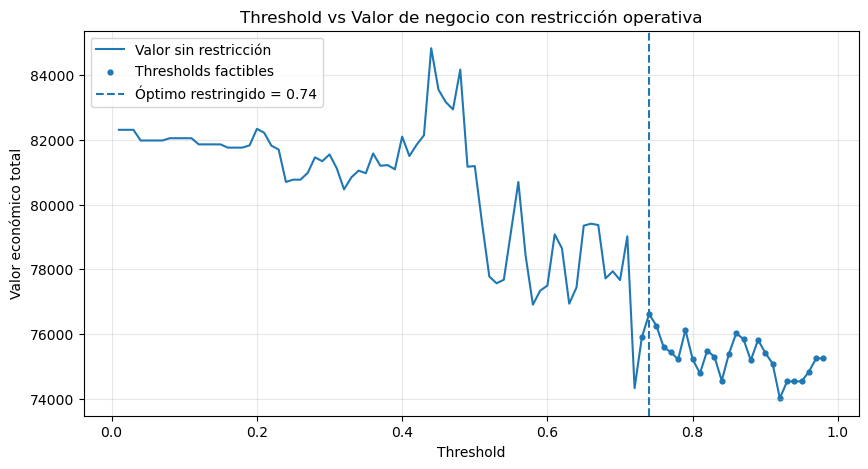

In [115]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_thresholds["threshold"],
    df_thresholds["valor_total"],
    label="Valor sin restricción"
)

plt.scatter(
    df_thresholds_restricted["threshold"],
    df_thresholds_restricted["valor_total"],
    s=12,
    label="Thresholds factibles"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Óptimo restringido = {best_threshold:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Valor económico total")
plt.title("Threshold vs Valor de negocio con restricción operativa")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Velocímetro de Business Value

In [116]:


def speedometer_business_value(
    value,
    vmin,
    vmax,
    title="Business Value",
    save_path=None
):
    if vmax == vmin:
        vmax = vmin + 1

    value = float(np.clip(value, vmin, vmax))

    def val_to_angle(v):
        frac = (v - vmin) / (vmax - vmin)
        return -90 + 180 * frac

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.set_aspect("equal")
    ax.axis("off")

    center = (0, 0)
    r_outer = 1.0
    r_inner = 0.72

    rango = vmax - vmin

    zonas = [
        (vmin, vmin + rango * 0.40, "#e74c3c"),
        (vmin + rango * 0.40, vmin + rango * 0.70, "#f1c40f"),
        (vmin + rango * 0.70, vmax, "#2ecc71")
    ]

    for zmin, zmax, color in zonas:
        arc = Wedge(
            center,
            r_outer,
            theta1=val_to_angle(zmin),
            theta2=val_to_angle(zmax),
            width=r_outer - r_inner,
            color=color,
            alpha=0.8
        )
        ax.add_patch(arc)

    outer_edge = Circle(center, r_outer, fill=False, linewidth=1.2)
    inner_edge = Circle(center, r_inner, fill=False, linewidth=1.0)

    ax.add_patch(outer_edge)
    ax.add_patch(inner_edge)

    tick_vals = np.linspace(vmin, vmax, 7)

    for tv in tick_vals:
        ang = np.deg2rad(val_to_angle(tv))

        x_inner = r_inner * np.cos(ang)
        y_inner = r_inner * np.sin(ang)

        x_outer = r_outer * np.cos(ang)
        y_outer = r_outer * np.sin(ang)

        ax.plot(
            [x_inner, x_outer],
            [y_inner, y_outer],
            linewidth=1.5,
            color="black"
        )

        x_lab = (r_outer + 0.13) * np.cos(ang)
        y_lab = (r_outer + 0.13) * np.sin(ang)

        ax.text(
            x_lab,
            y_lab,
            f"{tv:,.0f}",
            ha="center",
            va="center",
            fontsize=8
        )

    ang = np.deg2rad(val_to_angle(value))

    needle_len = 0.95 * r_outer

    x_tip = needle_len * np.cos(ang)
    y_tip = needle_len * np.sin(ang)

    ax.add_line(
        Line2D(
            [0, x_tip],
            [0, y_tip],
            linewidth=4,
            color="black"
        )
    )

    ax.add_patch(Circle(center, 0.055, color="black"))

    ax.text(
        0,
        -0.18,
        f"USD {value:,.0f}",
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold"
    )

    ax.text(
        0,
        -0.36,
        "Valor Económico Esperado",
        ha="center",
        va="center",
        fontsize=10
    )

    ax.set_title(title, pad=15, fontsize=14)

    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-0.60, 1.20)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    return fig, ax

,threshold_optimo_restringido,business_value_restringido,valor_minimo_evaluado,valor_maximo_evaluado,max_pct_intervenido
0,0.74,76620.0,74020,84830,0.3


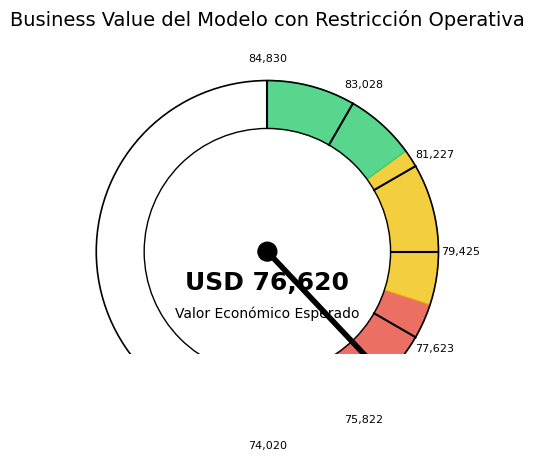

In [117]:
business_value = best_restricted["valor_total"]

display(pd.DataFrame([{
    "threshold_optimo_restringido": best_threshold,
    "business_value_restringido": business_value,
    "valor_minimo_evaluado": df_thresholds["valor_total"].min(),
    "valor_maximo_evaluado": df_thresholds["valor_total"].max(),
    "max_pct_intervenido": MAX_INTERVENTION_RATE
}]))

fig, ax = speedometer_business_value(
    value=business_value,
    vmin=df_thresholds["valor_total"].min(),
    vmax=df_thresholds["valor_total"].max(),
    title="Business Value del Modelo con Restricción Operativa",
    save_path="../models/business_value_speedometer.png"
)

plt.show()

Comparación de escenarios de negocio

In [118]:


y_pred_none = np.zeros(len(y_test), dtype=int)
y_pred_all = np.ones(len(y_test), dtype=int)
y_pred_unrestricted = (y_proba >= best_unrestricted["threshold"]).astype(int)
y_pred_restricted = (y_proba >= best_threshold).astype(int)

escenarios = []

for nombre, pred in [
    ("No intervenir", y_pred_none),
    ("Intervenir a todos", y_pred_all),
    ("Modelo threshold 0.5", y_pred_05),
    ("Modelo óptimo sin restricción", y_pred_unrestricted),
    ("Modelo óptimo con restricción", y_pred_restricted)
]:
    row = calcular_valor(y_test, pred)
    row["escenario"] = nombre
    escenarios.append(row)

df_escenarios = pd.DataFrame(escenarios)

df_escenarios = df_escenarios[
    [
        "escenario",
        "tn", "fp", "fn", "tp",
        "empleados_intervenidos",
        "pct_intervenido",
        "precision",
        "recall",
        "f1",
        "valor_total",
        "valor_promedio_por_empleado"
    ]
].sort_values("valor_total", ascending=False)

display(df_escenarios)

,escenario,tn,fp,fn,tp,empleados_intervenidos,pct_intervenido,precision,recall,f1,valor_total,valor_promedio_por_empleado
3,Modelo óptimo sin restricción,397,1971,63,369,2340,0.835714,0.157692,0.854167,0.266234,84830,30.296429
1,Intervenir a todos,0,2368,0,432,2800,1.000000,0.154286,1.000000,0.267327,82240,29.371429
2,Modelo threshold 0.5,545,1823,98,334,2157,0.770357,0.154845,0.773148,0.258015,81190,28.996429
4,Modelo óptimo con restricción,1754,614,321,111,725,0.258929,0.153103,0.256944,0.191876,76620,27.364286
0,No intervenir,2368,0,432,0,0,0.000000,0.000000,0.000000,0.000000,75200,26.857143


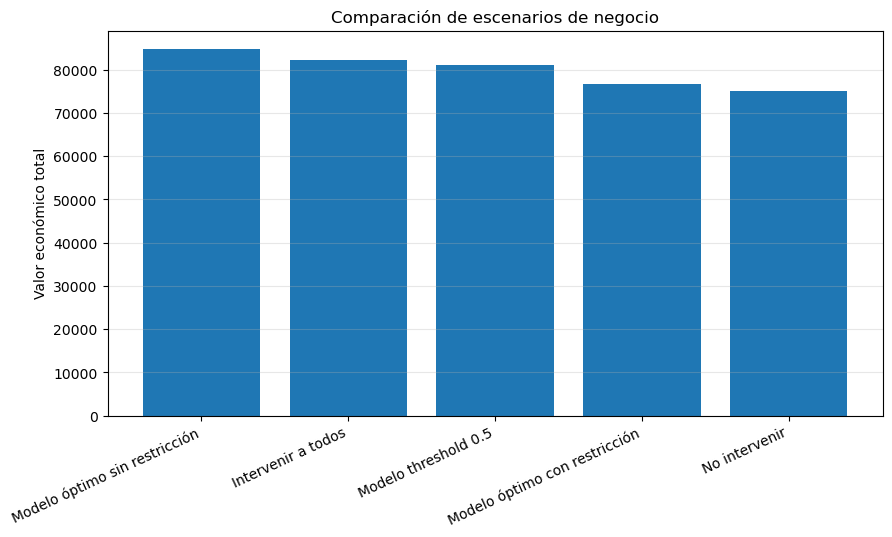

In [119]:
plt.figure(figsize=(10, 5))

plt.bar(
    df_escenarios["escenario"],
    df_escenarios["valor_total"]
)

plt.xticks(rotation=25, ha="right")
plt.ylabel("Valor económico total")
plt.title("Comparación de escenarios de negocio")
plt.grid(axis="y", alpha=0.3)

plt.show()

Métricas con threshold restringido

In [120]:


print(classification_report(
    y_test,
    y_pred_restricted,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.85      0.74      0.79      2368
           1       0.15      0.26      0.19       432

    accuracy                           0.67      2800
   macro avg       0.50      0.50      0.49      2800
weighted avg       0.74      0.67      0.70      2800



In [121]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_restricted).ravel()

print("Matriz de confusión con threshold restringido")
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

Matriz de confusión con threshold restringido
TN: 1754
FP: 614
FN: 321
TP: 111


In [122]:
business_metrics = pd.DataFrame([{
    "modelo": str(MODEL_PATH.name),
    "threshold_optimo_restringido": best_threshold,
    "max_pct_intervenido": MAX_INTERVENTION_RATE,
    "accuracy": accuracy_score(y_test, y_pred_restricted),
    "precision": precision_score(y_test, y_pred_restricted, zero_division=0),
    "recall": recall_score(y_test, y_pred_restricted, zero_division=0),
    "f1": f1_score(y_test, y_pred_restricted, zero_division=0),
    "roc_auc": auc_roc,
    "average_precision": avg_precision,
    "base_rate_attrition": base_rate,
    "valor_total": best_restricted["valor_total"],
    "valor_promedio_por_empleado": best_restricted["valor_promedio_por_empleado"],
    "empleados_intervenidos": int(y_pred_restricted.sum()),
    "pct_intervenido": y_pred_restricted.mean()
}])

display(business_metrics)

,modelo,threshold_optimo_restringido,max_pct_intervenido,accuracy,precision,recall,f1,roc_auc,average_precision,base_rate_attrition,valor_total,valor_promedio_por_empleado,empleados_intervenidos,pct_intervenido
0,validated_final_model.pkl,0.74,0.3,0.666071,0.153103,0.256944,0.191876,0.497517,0.152855,0.154286,76620.0,27.364286,725,0.258929


 Gain Curve

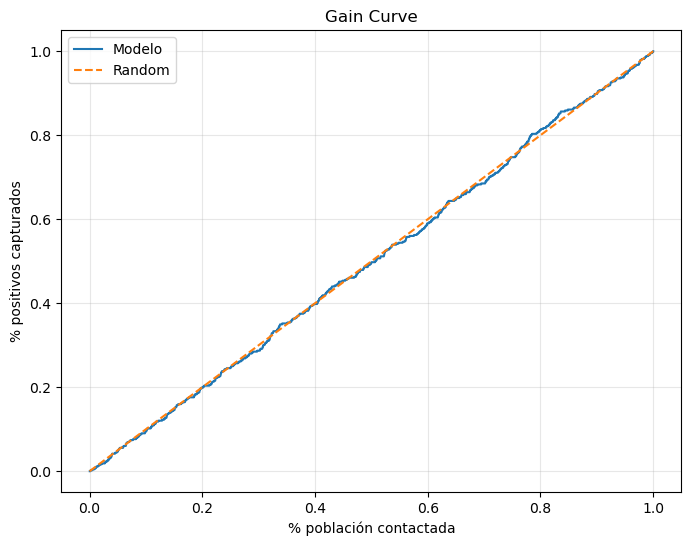

In [123]:


order = np.argsort(-y_proba)

y_sorted = y_test.values[order]

cum_pos = np.cumsum(y_sorted)

total_pos = y_test.sum()

x = np.arange(1, len(y_test) + 1) / len(y_test)

y_gain = cum_pos / total_pos

plt.figure(figsize=(8, 6))

plt.plot(x, y_gain, label="Modelo")
plt.plot([0, 1], [0, 1], "--", label="Random")

plt.xlabel("% población contactada")
plt.ylabel("% positivos capturados")
plt.title("Gain Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

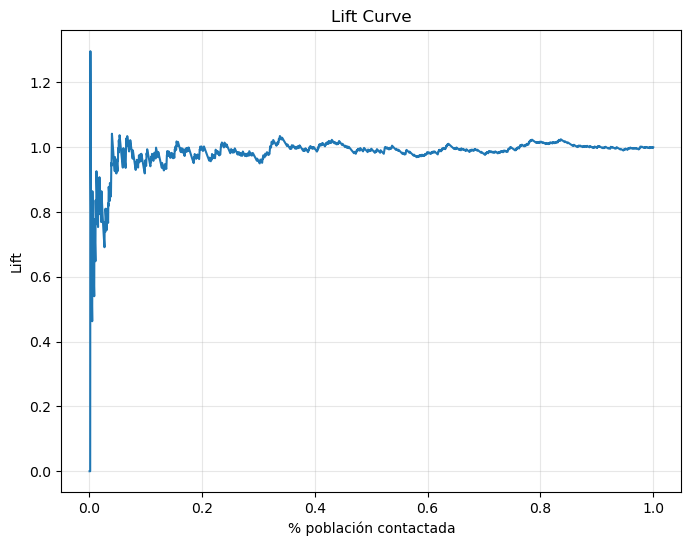

In [124]:
# 13. Lift Curve
# =========================================================

lift = y_gain / x

plt.figure(figsize=(8, 6))

plt.plot(x, lift)

plt.xlabel("% población contactada")
plt.ylabel("Lift")
plt.title("Lift Curve")
plt.grid(alpha=0.3)

plt.show()

In [125]:
# 14. Top-k operativo
# =========================================================

top_k_results = []

for k in [0.10, 0.20, 0.30]:
    n_top = int(len(y_test) * k)

    top_idx = np.argsort(-y_proba)[:n_top]

    y_pred_topk = np.zeros(len(y_test), dtype=int)
    y_pred_topk[top_idx] = 1

    row = calcular_valor(y_test, y_pred_topk)
    row["estrategia"] = f"Top {int(k*100)}% riesgo"
    row["top_k"] = k

    top_k_results.append(row)

df_topk = pd.DataFrame(top_k_results)

df_topk = df_topk[
    [
        "estrategia",
        "top_k",
        "tn", "fp", "fn", "tp",
        "empleados_intervenidos",
        "pct_intervenido",
        "precision",
        "recall",
        "f1",
        "valor_total",
        "valor_promedio_por_empleado"
    ]
].sort_values("valor_total", ascending=False)

display(df_topk)

,estrategia,top_k,tn,fp,fn,tp,empleados_intervenidos,pct_intervenido,precision,recall,f1,valor_total,valor_promedio_por_empleado
1,Top 20% riesgo,0.2,1894,474,346,86,560,0.2,0.153571,0.199074,0.173387,76420,27.292857
0,Top 10% riesgo,0.1,2129,239,391,41,280,0.1,0.146429,0.094907,0.115169,74870,26.739286
2,Top 30% riesgo,0.3,1652,716,308,124,840,0.3,0.147619,0.287037,0.194969,74680,26.671429


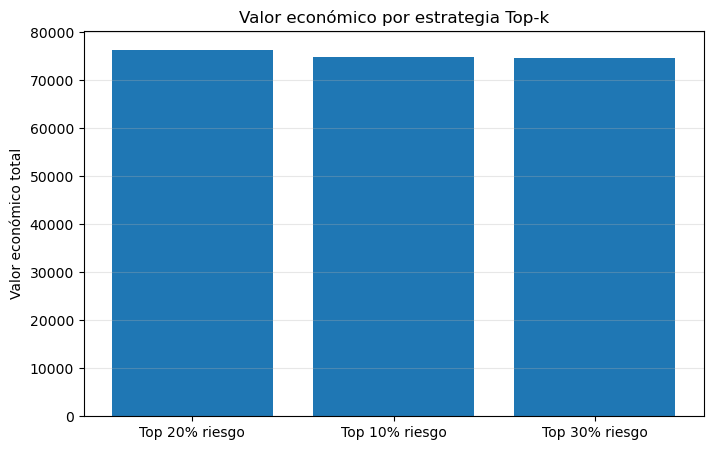

In [126]:
plt.figure(figsize=(8, 5))

plt.bar(
    df_topk["estrategia"],
    df_topk["valor_total"]
)

plt.ylabel("Valor económico total")
plt.title("Valor económico por estrategia Top-k")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [127]:
# 15. Análisis por deciles de riesgo
# =========================================================

df_riesgo = X_test.copy()

df_riesgo["attrition_real"] = y_test.values
df_riesgo["prob_attrition"] = y_proba

df_riesgo["decil_riesgo"] = pd.qcut(
    df_riesgo["prob_attrition"],
    q=10,
    labels=False,
    duplicates="drop"
)

resumen_deciles = (
    df_riesgo
    .groupby("decil_riesgo")
    .agg(
        empleados=("attrition_real", "count"),
        attrition_reales=("attrition_real", "sum"),
        tasa_attrition=("attrition_real", "mean"),
        prob_promedio=("prob_attrition", "mean")
    )
    .reset_index()
    .sort_values("decil_riesgo", ascending=False)
)

display(resumen_deciles)

,decil_riesgo,empleados,attrition_reales,tasa_attrition,prob_promedio
9,9,280,41,0.146429,0.893357
8,8,280,45,0.160714,0.802198
7,7,280,38,0.135714,0.744002
6,6,280,48,0.171429,0.700794
5,5,280,43,0.153571,0.653989
4,4,280,40,0.142857,0.610815
3,3,280,41,0.146429,0.561220
2,2,280,55,0.196429,0.505558
1,1,280,37,0.132143,0.433830
0,0,280,44,0.157143,0.297101


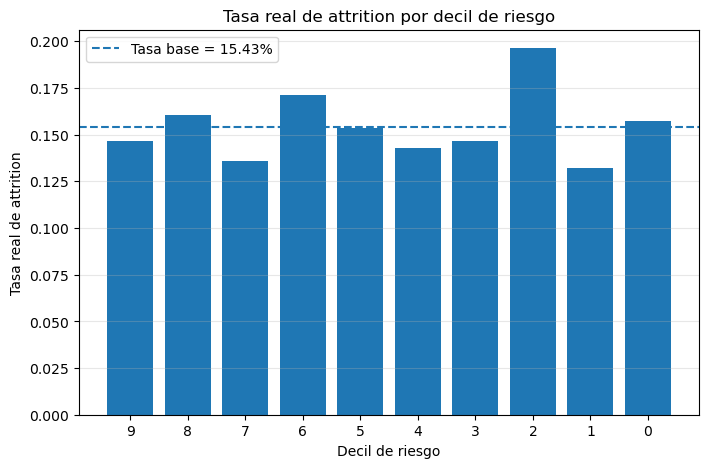

In [128]:
plt.figure(figsize=(8, 5))

plt.bar(
    resumen_deciles["decil_riesgo"].astype(str),
    resumen_deciles["tasa_attrition"]
)

plt.axhline(
    base_rate,
    linestyle="--",
    label=f"Tasa base = {base_rate:.2%}"
)

plt.xlabel("Decil de riesgo")
plt.ylabel("Tasa real de attrition")
plt.title("Tasa real de attrition por decil de riesgo")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [129]:
# 16. Sensibilidad de supuestos de negocio
# =========================================================

sensitivity_results = []

benefit_tp_values = [100, 150, 200]
cost_fp_values = [-10, -20, -40]
cost_fn_values = [-100, -200, -300]

for btp in benefit_tp_values:
    for cfp in cost_fp_values:
        for cfn in cost_fn_values:
            values = []

            for t in thresholds:
                y_pred = (y_proba >= t).astype(int)
                pct_intervenido = y_pred.mean()

                if pct_intervenido > MAX_INTERVENTION_RATE:
                    continue

                tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

                valor = (
                    tp * btp +
                    fp * cfp +
                    fn * cfn +
                    tn * benefit_tn
                )

                values.append({
                    "benefit_tp": btp,
                    "cost_fp": cfp,
                    "cost_fn": cfn,
                    "threshold": t,
                    "pct_intervenido": pct_intervenido,
                    "valor_total": valor
                })

            tmp = pd.DataFrame(values)

            if not tmp.empty:
                best_tmp = tmp.loc[tmp["valor_total"].idxmax()]
                sensitivity_results.append(best_tmp)

df_sensitivity = pd.DataFrame(sensitivity_results)

display(df_sensitivity.sort_values("valor_total", ascending=False).head(10))

,benefit_tp,cost_fp,cost_fn,threshold,pct_intervenido,valor_total
24,200.0,-10.0,-100.0,0.97,0.002143,75200.0
24,200.0,-20.0,-100.0,0.97,0.002143,75150.0
24,150.0,-10.0,-100.0,0.97,0.002143,75150.0
24,100.0,-10.0,-100.0,0.97,0.002143,75100.0
24,150.0,-20.0,-100.0,0.97,0.002143,75100.0
24,200.0,-40.0,-100.0,0.97,0.002143,75050.0
24,100.0,-20.0,-100.0,0.97,0.002143,75050.0
24,150.0,-40.0,-100.0,0.97,0.002143,75000.0
24,100.0,-40.0,-100.0,0.97,0.002143,74950.0
1,200.0,-10.0,-200.0,0.74,0.258929,39560.0


In [130]:
# 17. Diagnóstico ejecutivo
# =========================================================

valor_intervenir_todos = df_escenarios[
    df_escenarios["escenario"] == "Intervenir a todos"
]["valor_total"].iloc[0]

valor_modelo_restringido = df_escenarios[
    df_escenarios["escenario"] == "Modelo óptimo con restricción"
]["valor_total"].iloc[0]

diagnostico = pd.DataFrame([{
    "modelo": str(MODEL_PATH.name),
    "tasa_base_attrition": base_rate,
    "average_precision_modelo": avg_precision,
    "mejora_avg_precision_vs_base_rate": avg_precision - base_rate,
    "roc_auc": auc_roc,
    "threshold_optimo_restringido": best_threshold,
    "max_pct_intervenido": MAX_INTERVENTION_RATE,
    "valor_modelo_restringido": valor_modelo_restringido,
    "valor_intervenir_todos": valor_intervenir_todos,
    "diferencia_vs_intervenir_todos": valor_modelo_restringido - valor_intervenir_todos,
    "interpretacion": (
        "Modelo con baja separabilidad; usar solo como alerta preliminar y con restricción operativa"
        if auc_roc < 0.60
        else "Modelo con capacidad discriminativa aceptable"
    )
}])

display(diagnostico)

,modelo,tasa_base_attrition,average_precision_modelo,mejora_avg_precision_vs_base_rate,roc_auc,threshold_optimo_restringido,max_pct_intervenido,valor_modelo_restringido,valor_intervenir_todos,diferencia_vs_intervenir_todos,interpretacion
0,validated_final_model.pkl,0.154286,0.152855,-0.00143,0.497517,0.74,0.3,76620,82240,-5620,Modelo con baja separabilidad; usar solo como ...


In [131]:
# 18. Guardar resultados
# =========================================================

df_thresholds.to_csv(
    MODELS_DIR / "business_threshold_analysis.csv",
    index=False
)

df_thresholds_restricted.to_csv(
    MODELS_DIR / "business_threshold_analysis_restricted.csv",
    index=False
)

df_escenarios.to_csv(
    MODELS_DIR / "business_value_scenarios.csv",
    index=False
)

business_metrics.to_csv(
    MODELS_DIR / "business_value_final_metrics.csv",
    index=False
)

df_topk.to_csv(
    MODELS_DIR / "business_value_topk.csv",
    index=False
)

resumen_deciles.to_csv(
    MODELS_DIR / "risk_deciles_summary.csv",
    index=False
)

df_sensitivity.to_csv(
    MODELS_DIR / "business_value_sensitivity.csv",
    index=False
)

diagnostico.to_csv(
    MODELS_DIR / "business_value_diagnostic.csv",
    index=False
)

print("Resultados de Business Value guardados correctamente.")

Resultados de Business Value guardados correctamente.


In [132]:
# =========================================================
# 19. Conclusión automática
# =========================================================
mejor_escenario= df_escenarios.iloc[0]["escenario"]
mejor_valor = df_escenarios.iloc[0]["valor_total"]

print("Conclusión de Business Value:")
print(f"- Modelo evaluado: {MODEL_PATH.name}")
print(f"- Mejor escenario económico general: {mejor_escenario}")
print(f"- Valor económico del mejor escenario general: USD {mejor_valor:,.2f}")
print(f"- Threshold óptimo restringido: {best_threshold:.2f}")
print(f"- Límite operativo aplicado: {MAX_INTERVENTION_RATE:.0%} de empleados intervenidos")
print(f"- Valor económico del modelo con restricción: USD {valor_modelo_restringido:,.2f}")
print(f"- AUC-ROC del modelo: {auc_roc:.3f}")
print(f"- Average Precision del modelo: {avg_precision:.3f}")
print("- El modelo debe interpretarse como herramienta de alerta temprana.")
print("- No se recomienda intervenir a casi toda la población solo porque el umbral económico sin restricción lo sugiera.")

Conclusión de Business Value:
- Modelo evaluado: validated_final_model.pkl
- Mejor escenario económico general: Modelo óptimo sin restricción
- Valor económico del mejor escenario general: USD 84,830.00
- Threshold óptimo restringido: 0.74
- Límite operativo aplicado: 30% de empleados intervenidos
- Valor económico del modelo con restricción: USD 76,620.00
- AUC-ROC del modelo: 0.498
- Average Precision del modelo: 0.153
- El modelo debe interpretarse como herramienta de alerta temprana.
- No se recomienda intervenir a casi toda la población solo porque el umbral económico sin restricción lo sugiera.
